In [2]:
import cv2
import os
from matplotlib import pyplot as plt
from google.colab import drive


drive.mount('/content/drive')
pathDrive = '/content/drive/MyDrive/AWSD/VC/YOLO'
path = '/content/dataset_local'

!cp {pathDrive}/dataset.zip /content/
!unzip -q /content/dataset.zip -d /content/dataset_local

clases = ["estrella","luna","nube","sol"]



Mounted at /content/drive


In [4]:
!pip -q install ultralytics
from ultralytics import YOLO

# Debug

In [5]:
def debug_bbox(image_path, label_path):
    # 1. Cargar la imagen
    img = cv2.imread(image_path)
    h, w, _ = img.shape

    # 2. Leer el archivo de etiquetas
    if not os.path.exists(label_path):
        print(f"No se encontró el label: {label_path}")
        return

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        # Formato YOLO: class x_center y_center width height
        data = line.split()
        x_c, y_c, wb, hb = map(float, data[1:])

        # 3. Convertir de normalizado (0-1) a píxeles
        # YOLO usa el centro, OpenCV necesita la esquina superior izquierda (x1, y1)
        x1 = int((x_c - wb / 2) * w)
        y1 = int((y_c - hb / 2) * h)
        x2 = int((x_c + wb / 2) * w)
        y2 = int((y_c + hb / 2) * h)

        if i == 0:
            color = (255,255,0)
        else:
            color = (255,0,0)

        # 4. Dibujar el rectángulo (Verde, grosor 2)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f"{clases[int(data[0])]}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # 5. Mostrar resultado
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

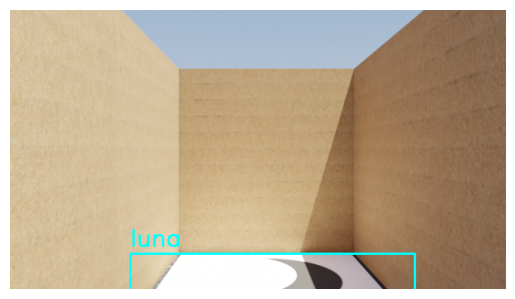

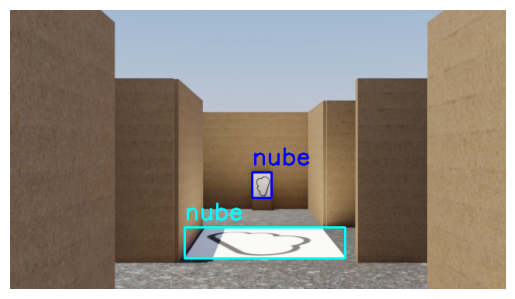

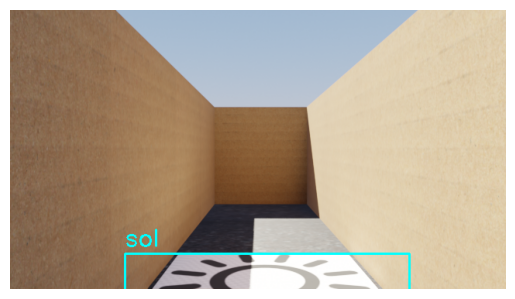

In [7]:
for i in range(0,3):
    img_p =  f"{path}/dataset/val/images/img_{i}.png"
    lab_p = f"{path}/dataset/val/labels/img_{i}.txt"
    debug_bbox(img_p, lab_p)

# Train

In [12]:
from ultralytics import YOLO

In [19]:
model = YOLO('yolov8n.pt')
modelName = 'test_v1'
results = model.train(
    data=f'{path}/dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name=modelName
)



Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_local/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=test_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [20]:
modelName = 'test_v1'
!mkdir -p {pathDrive}/entrenamientos/{modelName}/
!cp -r /content/runs/detect/{modelName} {pathDrive}/entrenamientos/


In [21]:
!ls {pathDrive}/entrenamientos/

test_v1


In [18]:
!rm -rf /content/runs/detect/*

# Validation